## Subgraph - As a Node

In [11]:
from IPython.display import display, Image
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from pydantic import BaseModel, Field

In [12]:
load_dotenv(override=True)
llm = init_chat_model(model="nvidia/nemotron-3-super-120b-a12b", model_provider="nvidia", temperature=0.0)

### Shared State across parent and subgraph

In [13]:
class ContentState(MessagesState):
    topic: str
    generated_content: str
    to_lang: str
    translated_content: str
    other_meta_info: str


### Subgraph - This helps as Language Translator

In [14]:
def translate_content(state: ContentState):
    prompt = f""" Translate the following text into {state["to_lang"]}. Keep it simple, natural and clear. Do not add
    extra content.
    Text: {state["generated_content"]} """.strip()
    response = llm.invoke(prompt).content
    return {"translated_content": response}

In [15]:
translator_workflow = StateGraph(ContentState)
translator_workflow.add_node("translate", translate_content)
translator_workflow.add_edge(START, "translate")
translator_workflow.add_edge("translate", END)
translator_graph = translator_workflow.compile()

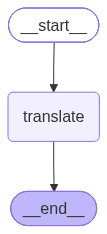

In [16]:
display(Image(translator_graph.get_graph().draw_mermaid_png()))

### Parent Graph - Content Generator - Identify the Language to Translate

In [17]:
class DetectTranslation(BaseModel):
    topic: str = Field(..., description="Short title of the topic to generate content about")
    to_lang: str = Field(
        default="Tamil",
        description=(
            "Target translation language as a single language name only "
            "(e.g. Tamil, Hindi, French). "
            "If the user does not ask for translation, always return Tamil. "
            "Do not return English or any explanation text."
        ),
    )
    other_meta_info: str = Field(
        default="",
        description=(
            "Extra generation constraints only, such as word count, line count, tone, or style "
            "(e.g. '50 words', 'formal tone'). "
            "Do not repeat the topic or language here. Empty string if none."
        ),
    )


In [21]:
def identify_topic_and_detect_translation(state: ContentState):
    usr_msg = state["messages"][-1].content
    print(f"usr msg is: {usr_msg}")
    llm_with_stru_output = llm.with_structured_output(DetectTranslation)
    prompt = (
        "From the user request below, extract:\n"
        "1) topic\n"
        "2) to_lang - language name only; if translation is not requested, use Tamil\n"
        "3) other_meta_info - constraints like word count, tone, or style\n\n"
        f"User request:\n{usr_msg}"
    )
    response: DetectTranslation = llm_with_stru_output.invoke(prompt)
    print(f"res: {response}")
    return {
        "topic": response.topic,
        "to_lang": response.to_lang,
        "other_meta_info": response.other_meta_info,
    }

def generate_content(state: ContentState):
    content_result = llm.invoke(f"You are an content generator expert, helps to create a write ups on {state["topic"]} and keep maintain the {state["other_meta_info"]} as constraints")
    return {
        "generated_content": content_result.content
    }

In [22]:
content_workflow = StateGraph(ContentState)
content_workflow.add_node("identify", identify_topic_and_detect_translation)
content_workflow.add_node("generate", generate_content)

## added subgraph instead of wrap'd function invoke subgraph
content_workflow.add_node("translate", translator_graph)

content_workflow.add_edge(START, "identify")
content_workflow.add_edge("identify", "generate")
content_workflow.add_edge("generate", "translate")
content_workflow.add_edge("translate", END)

content_graph = content_workflow.compile()

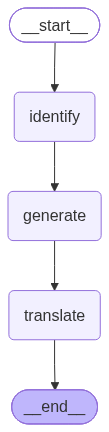

In [23]:
display(Image(content_graph.get_graph().draw_mermaid_png()))

In [24]:
# identify_topic_and_detect_translation({
#     "messages":[HumanMessage(content ="Explain in 2 to 3 lines about agentic ai and good to translate into spanish?")]
# })

final_result = content_graph.invoke({
    "messages": [HumanMessage(content="Explain in 2 lines about ai agent and agentic ai?")]
})
print(final_result)

usr msg is: Explain in 2 lines about ai agent and agentic ai?
res: topic='ai agent and agentic ai' to_lang='Tamil' other_meta_info='Explain in 2 lines'
{'messages': [HumanMessage(content='Explain in 2 lines about ai agent and agentic ai?', additional_kwargs={}, response_metadata={}, id='a6940e07-6ec2-464a-a266-3d2815183260')], 'topic': 'ai agent and agentic ai', 'generated_content': 'AI agents execute predefined tasks within set boundaries, reacting to specific inputs or triggers. Agentic AI autonomously sets goals, plans multi-step actions, and adapts to achieve objectives without constant human direction.', 'to_lang': 'Tamil', 'translated_content': 'AI agents, குறிப்பிட்ட வரம்புகளுக்குள் முன்னறிவதரப்பட்ட பணிகளை செயல்படுத்துகின்றன; அவை குறிப்பிட்ட உள்ளீடுகள் அல்லது தூண்டுகோல்களுக்கு பதிலளிக்கின்றன. Agentic AI, தானாக இலக்குகளை அமைக்க, பல‑முறை நடவடிக்கைகளை திட்டமிட, நிலையான மனித வழிகாட்டுதலின் இல்லாமல் இலக்குகளை அடைய திறமையாக ஏற்றுக்கொள்கிறது.', 'other_meta_info': 'Explain in 2 lines'}
